In [25]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression
data:pd.DataFrame = pd.read_csv("heart.csv")
data = encode_sex("heart.csv")



Saved encoded file to: heart_encoded.csv


In [ ]:
labels = pd.read_csv("heart.csv")["HeartDisease"]


0    0
1    1
2    0
3    1
4    0
Name: HeartDisease, dtype: int64


In [8]:
print(data.dtypes)


Age                    int64
Sex                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
ExerciseAngina         int64
Oldpeak              float64
ST_Slope               int64
HeartDisease           int64
ChestPainType_ASY      int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_LVH         int64
RestingECG_Normal      int64
RestingECG_ST          int64
dtype: object


In [27]:
def encode_sex(input_file, output_file=None):
    df = pd.read_csv(input_file)

    if 'Sex' not in df.columns:
        raise ValueError("Column 'Sex' not found in the dataset.")

    df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})

    if 'ExerciseAngina' not in df.columns:
        raise ValueError("Column 'ExerciseAngina' not found in the dataset.")

    df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

    if 'ST_Slope' not in df.columns:
        raise ValueError("Column 'ST_Slope' not found in the dataset.")

    df['ST_Slope'] = df['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})

    if 'ChestPainType' not in df.columns:
        raise ValueError("Column 'ChestPainType' not found in the dataset.")

    df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG'], dtype=int)

    if output_file is None:
        output_file = input_file.replace('.csv', '_encoded.csv')

    df.to_csv(output_file, index=False)
    print(f"Saved encoded file to: {output_file}")
    return df

In [28]:
model = LogisticRegression(penalty="l1", solver="liblinear")
X = data.drop(columns = ["HeartDisease"])
model.fit(X, labels)



/Users/samuelgair/Desktop/project2 ml4h/Interpretable_ML_for_healthcare/.virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/samuelgair/Desktop/project2 ml4h/Interpretable_ML_for_healthcare/.virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

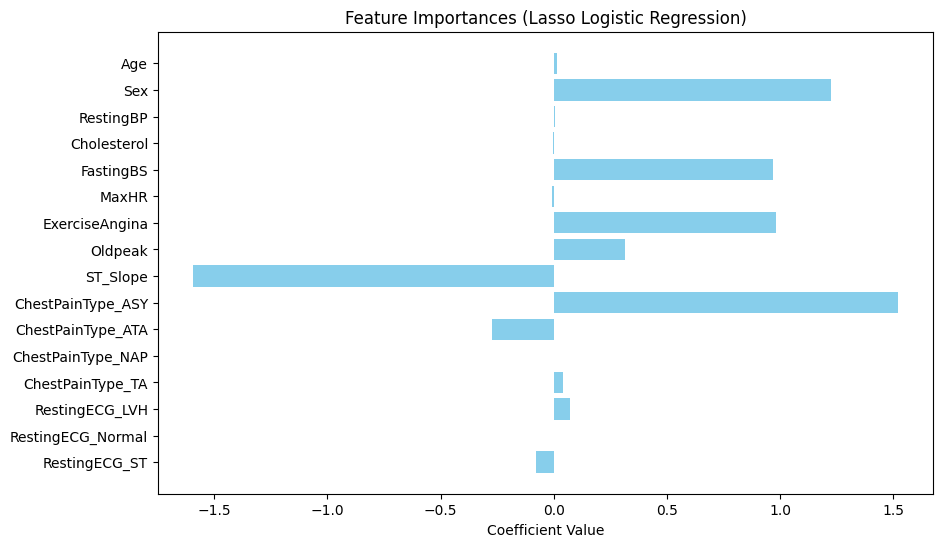

In [29]:
weights = model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'value' : weights})
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# We plot the actual Weight (not absolute) so we can see positive/negative impact
plt.barh(importance_df['feature'], importance_df['value'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importances (Lasso Logistic Regression)')
plt.gca().invert_yaxis() # Puts the most important feature at the top
plt.show()